# Exploratory Data Analysis

## Purpose

The purpose of this EDA is to explore patterns in the notable people dataset and understand how birth month may relate to broader characteristics such as occupation, geography, gender, and historical time period.

This analysis will focus on identifying interesting trends, checking data quality, exploring missing values, and comparing groups before deciding which variables may be useful for deeper analysis or storytelling.

At this stage, missing values will not be filled automatically. I will first examine where null values appear and decide whether they should be kept, removed, or handled later depending on the column and analysis question.

# Exploratory Analysis of Notable People Dataset

## Dataset: 
Biographical dataset of notable people from Wikidata, born in the 20th and 21st centuries. 

https://www.kaggle.com/datasets/qqsolov/notable-people-dataset-wikidata-based/data

## Project Overview

This notebook explores patterns in a dataset of notable people, focusing on geography, occupation, gender, birth date, awards, and broader groupings of people.

The goal is to identify interesting relationships in the data, compare groups, and look for patterns that may be worth exploring further.

---

## Questions I Want to Explore

### 1. Countries and Occupations

- Do certain countries have more notable people in specific occupation groups?
- Which occupation groups are most common within each country?
- Which countries have the highest diversity of occupation groups?

---

### 2. Gender and Occupation

- What is the overall gender breakdown in the dataset?
- How does gender distribution vary by occupation?
- How does gender distribution vary by broader occupation group?
- Which occupations or occupation groups are most male-dominated, female-dominated, or more balanced?
- Are there occupation groups where gender representation changes over time?

---

### 3. Birth Date, Time Period, and Occupation

- Is there a relationship between birth year and occupation type?
- Are some occupation groups more common among people born in earlier or later historical periods?
- How has the distribution of notable people by occupation changed over time?
- Are certain fields more represented in modern birth cohorts?
- Are there any unusual patterns by birth month or birth season?

---

### 4. Awards and Recognition

- Does award documentation vary by gender?
- Which occupation groups are most likely to have awards recorded?
- Are certain occupations overrepresented among people with awards?

---

### 5. Pattern Discovery

- Are there unexpected combinations of features that appear frequently?
- Can people be grouped into meaningful categories without using a target variable?
- Are there clusters of people who share similar characteristics based on country, occupation group, gender, and birth year?

---

## Ways I Will Analyze the Data

### Descriptive Statistics

I will start by summarizing the dataset with counts, percentages, and basic distributions. This includes looking at the most common countries, occupations, occupation groups, genders, and birth years.

---

### Grouped Comparisons

I will compare categories using grouped summaries. For example, I can compare birth year by occupation group, gender distribution by occupation group, or award documentation by gender.

---

### Cross-Tabulations

I will use cross-tabulations to compare categorical variables, such as country and occupation group, occupation group and gender, or gender and award status. I will look at both raw counts and percentages so large groups do not dominate the results.

---

### Time-Based Analysis

I will create new date features from `date_of_birth`, such as birth year, birth decade, and birth month. This will help explore how occupation and gender patterns change over time.

---

### Visualization

I will use charts to make patterns easier to understand. Possible visualizations include bar charts, stacked bar charts, heatmaps, line charts, histograms, and box plots.

---

### Possible Machine Learning Extension

Most of this notebook is exploratory data analysis. However, I may also try unsupervised learning, such as clustering people based on country, occupation group, gender, and birth year, to see whether meaningful groups appear naturally in the data.

---

## Important Considerations

This dataset represents notable people, not the general population. Patterns should be interpreted as trends within this dataset, not as universal claims about countries, genders, or occupations.

The results may also reflect historical, geographic, gender, documentation, and selection biases.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
us_births_1 = pd.read_csv('data/raw/1995-2002.csv')
us_births_2 = pd.read_csv('data/raw/2003-2006.csv')
notable = pd.read_parquet('data/raw/npd_wikidata.parquet')

In [3]:
notable.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417937 entries, 0 to 417936
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   wikidata_url              417937 non-null  string        
 1   label                     417937 non-null  string        
 2   name_in_native_languages  100026 non-null  string        
 3   pseudonyms                12879 non-null   string        
 4   sex_or_gender             417526 non-null  string        
 5   date_of_birth             417937 non-null  datetime64[ns]
 6   place_of_birth            416462 non-null  string        
 7   country_of_birth          417937 non-null  string        
 8   date_of_death             115230 non-null  datetime64[ns]
 9   place_of_death            94520 non-null   string        
 10  country_of_death          94570 non-null   string        
 11  citizenships              399770 non-null  string        
 12  oc

In [4]:
notable['occupation_groups'].unique()

<StringArray>
[                                              'Arts & Culture',
                               'Arts & Culture; Public Figures',
                                               'Public Figures',
                           'Public Figures; Science & Academia',
                                           'Science & Academia',
                                                       'Sports',
                                                     'Business',
                                     'Business; Public Figures',
                                     'Arts & Culture; Business',
                                 'Business; Science & Academia',
                           'Arts & Culture; Science & Academia',
                     'Arts & Culture; Business; Public Figures',
           'Arts & Culture; Public Figures; Science & Academia',
                 'Arts & Culture; Business; Science & Academia',
                                   'Science & Academia; Sports',
           

In [5]:
notable['occupations'].unique()

<StringArray>
[                                        'screenwriter; film director; film producer',
                         'actor; stage actor; director; television actor; film actor',
                               'writer; poet; journalist; opinion journalist; critic',
                                                               'politician; diplomat',
                                                              'politician; economist',
                                                                           'musician',
                                        'engineer; mathematician; university teacher',
 'actor; stage actor; film director; television actor; film actor; cabaret performer',
                                        'university teacher; stage actor; film actor',
                                                             'politician; journalist',
 ...
                                                  'actor; aikidoka; judoka; karateka',
                        

In [6]:
notable['occupations'].value_counts(dropna=False).head(20)

occupations
politician                             52208
actor                                  13159
baseball player                        10531
ice hockey player                       9597
basketball player                       9061
singer                                  8173
writer                                  7880
American football player                7555
painter                                 5895
journalist                              5494
lawyer; politician                      5323
military personnel                      4374
musician                                3285
actor; film actor                       3225
businessperson                          2964
actor; television actor; film actor     2598
actor; television actor                 2510
writer; journalist                      2398
composer                                2172
chess player                            2110
Name: count, dtype: Int64

In [7]:
drop_col = notable[['place_of_death','date_of_death', 'country_of_death', 'signature_url', 'image_url',  'date_of_image']]
notable = notable.drop(columns=drop_col)

In [8]:
notable.shape

(417937, 12)

In [9]:
notable.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417937 entries, 0 to 417936
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   wikidata_url              417937 non-null  string        
 1   label                     417937 non-null  string        
 2   name_in_native_languages  100026 non-null  string        
 3   pseudonyms                12879 non-null   string        
 4   sex_or_gender             417526 non-null  string        
 5   date_of_birth             417937 non-null  datetime64[ns]
 6   place_of_birth            416462 non-null  string        
 7   country_of_birth          417937 non-null  string        
 8   citizenships              399770 non-null  string        
 9   occupations               417937 non-null  string        
 10  occupation_groups         417937 non-null  string        
 11  awards                    100007 non-null  string        
dtypes:

## Data Quality

Total rows: 417,937 rows and 12 columns. 
Core columns: `label`, `date_of_birth`, `country_of_birth`, `occupations`, and `occupation_groups`, `sex_or_gender`

Missing Values: 
`sex_or_gender` : will drop these since I can't infer - only 411 rows (about 0.1%)

Supplemental features that are not as important for my analysis: `awards`, `citizenships`, `place_of_birth`, `name_in_native_languages`, and `pseudonyms`

In [10]:
notable.isna().mean().sort_values(ascending=False) * 100

pseudonyms                  96.918435
awards                      76.071274
name_in_native_languages    76.066728
citizenships                 4.346827
place_of_birth               0.352924
sex_or_gender                0.098340
wikidata_url                 0.000000
label                        0.000000
date_of_birth                0.000000
country_of_birth             0.000000
occupations                  0.000000
occupation_groups            0.000000
dtype: float64

In [11]:
notable = notable.dropna(subset=['sex_or_gender'])

In [12]:
notable.shape

(417526, 12)

In [13]:
notable['sex_or_gender'].value_counts(dropna=False)

sex_or_gender
male                  311968
female                104673
trans woman              442
non-binary gender        281
trans man                 69
genderfluid               25
travesti                  12
genderqueer               11
agender                    9
intersex                   5
cisgender woman            5
two-spirit                 4
bigender                   4
intersex man               3
transgender                3
intersex woman             2
cisgender man              2
undisclosed gender         2
transmasculine             1
māhū                       1
kathoey                    1
female organism            1
transfeminine              1
faʻafafine                 1
Name: count, dtype: Int64

In [14]:
gender_map = {
    'male': 'male',
    'female': 'female',
    'trans woman': 'trans',
    'trans man': 'trans',
    'transfeminine': 'trans',
    'transmasculine': 'trans',
    'transgender': 'trans',
    'travesti': 'trans',
    'cisgender woman': 'female',
    'cisgender man': 'male',  
    'non-binary gender': 'non-binary / gender diverse',
    'genderfluid': 'non-binary / gender diverse',
    'genderqueer': 'non-binary / gender diverse',
    'agender': 'non-binary / gender diverse',
    'bigender': 'non-binary / gender diverse',
    'two-spirit': 'non-binary / gender diverse',
    'intersex': 'non-binary / gender diverse',
    'intersex man': 'non-binary / gender diverse',
    'intersex woman': 'non-binary / gender diverse',
    'māhū': 'non-binary / gender diverse',
    'kathoey': 'non-binary / gender diverse',
    'fa’afafine': 'non-binary / gender diverse',
    'undisclosed gender': 'undisclosed',
    'female organism': 'female'}

In [15]:
notable['gender_group'] = notable['sex_or_gender'].map(gender_map)

notable['gender_group'].value_counts(dropna=True)

gender_group
male                           311970
female                         104679
trans                             528
non-binary / gender diverse       346
undisclosed                         2
Name: count, dtype: int64

### Gender Grouping Results

After grouping related gender categories, the dataset is still heavily weighted toward male notable people, followed by female notable people. Trans, non-binary/gender diverse, and undisclosed groups are present but much smaller.

Because the smaller groups have limited sample sizes, gender-based comparisons should be interpreted carefully. For broad demographic comparisons, the strongest comparisons will likely be between male and female records.

In [16]:
notable['birth_month'] = notable['date_of_birth'].dt.month

In [17]:
notable['birth_month_name'] = notable['date_of_birth'].dt.month_name()

In [18]:
month_counts = notable['birth_month_name'].value_counts().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'])

month_counts

birth_month_name
January      75018
February     29850
March        32721
April        31857
May          32549
June         31026
July         31566
August       31520
September    31197
October      31093
November     29383
December     29746
Name: count, dtype: int64

In [19]:
month_percent = month_counts.div(month_counts.sum()).mul(100).round(2)

month_percent

birth_month_name
January      17.97
February      7.15
March         7.84
April         7.63
May           7.80
June          7.43
July          7.56
August        7.55
September     7.47
October       7.45
November      7.04
December      7.12
Name: count, dtype: float64

Text(0, 0.5, 'Number of People')

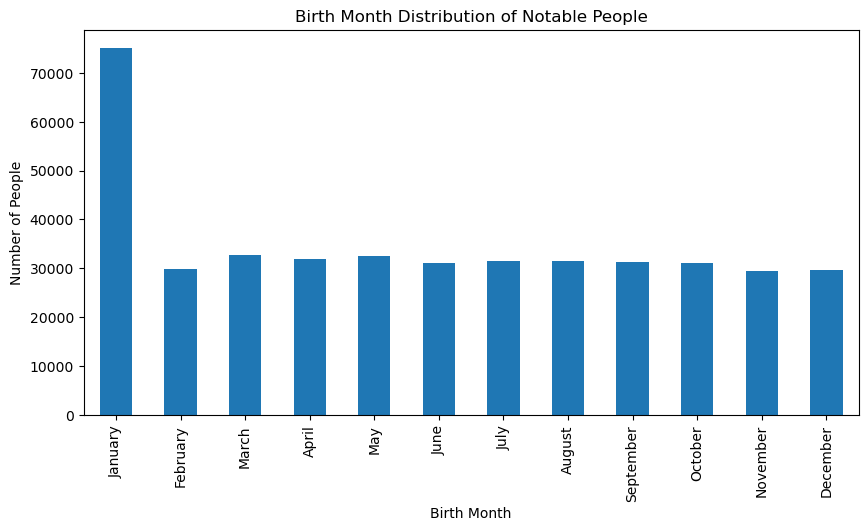

In [20]:
ax = month_counts.plot(kind='bar', figsize=(10, 5))

ax.set_title('Birth Month Distribution of Notable People')
ax.set_xlabel('Birth Month')
ax.set_ylabel('Number of People')

The birth month distribution shows that January has the highest count, more than double the other months. This is unusually high, so I would look into this further before making any conclusions about birth month patterns.

My first assumption is that some birth dates are incomplete or unknown and were defaulted to January.

In [21]:
notable['birth_day'] = notable['date_of_birth'].dt.day

In [22]:
jan_days = notable.loc[notable['birth_month_name'] == 'January', 'birth_day'].value_counts().sort_index()

jan_days.head()

birth_day
1    44343
2     1082
3     1070
4     1035
5     1063
Name: count, dtype: int64

### Exploration: January 1st birth dates

January 1st appears far more often than any other January day, which suggests that it could be a placeholder date for unknown birthdays. 

I'm curious to see the distribution of Janauary 1st birthdays by year - maybe it's skewed toward ancient/historic figures.

Since birth month patterns is one of the main things I'm analyzing, I want to have clear understanding before moving foward or keeping all of them in my analysis. I may move forward with a filtered version to addressed distortion.

In [23]:
notable['birth_year'] = notable['date_of_birth'].dt.year

In [24]:
notable['is_jan_1'] = notable['date_of_birth'].dt.strftime('%m-%d') == '01-01'

In [25]:
# use bins to help me segregate the years into timeframes that will be easier to work with
bins = [1899, 1909, 1919, 1929, 1939, 1949, 1959, 1969, 1979, 1989, 1999, 2009, 2019, 2029]

labels = [
    '1900s','1910s','1920s','1930s','1940s','1950s',
    '1960s','1970s','1980s','1990s','2000s','2010s',
    '2020s']

notable['birth_decade'] = pd.cut(notable['birth_year'], bins=bins, labels=labels)

In [26]:
notable['birth_year'].min(), notable['birth_year'].max()

(1901, 2015)

In [27]:
notable['date_of_birth'].min(), notable['date_of_birth'].max()

(Timestamp('1901-01-01 00:00:00'), Timestamp('2015-02-27 00:00:00'))

In trying to understand the Jan. 1 birth dates, I found that the timestamps for `date_of_birth` were limited to the years between 1901 and 2015. 

I'll have to limit my analysis to modern notable people and double check the data.

Because of this, I will treat this project as an analysis of modern notable people, not all notable people across history. Any conclusions about birth month patterns should be limited to this dataset.

### Flagging January 1 birthdays

January 1 appears way more often than expected, so I’m treating it as a possible placeholder date instead of assuming every Jan 1 birthday is real.

I’m not dropping these records because some of them are probably valid. Instead, I’m creating a flag so I can keep the data but still control for this issue later.

In [28]:
# Jan 1 is very high, so I want a simple flag I can use later (1 = possible placeholder birthday, 0 = normal birthday)
notable['jan1_flag'] = (
    (notable['birth_month'] == 1) & 
    (notable['birth_day'] == 1)).astype(int)

notable['jan1_flag'].value_counts()

jan1_flag
0    373183
1     44343
Name: count, dtype: int64

In [29]:
# Checking how big this issue is overall before deciding how much it matters
notable['jan1_flag'].value_counts(normalize=True).mul(100).round(2)

jan1_flag
0    89.38
1    10.62
Name: proportion, dtype: float64

In [30]:
# Checking Jan 1 by decade so I can see if this is tied to certain time periods
jan1_decade = notable.groupby('birth_decade')['jan1_flag'].mean().mul(100).round(2)

jan1_decade

C:\Users\cococ\AppData\Local\Temp\ipykernel_9824\628482200.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  jan1_decade = notable.groupby('birth_decade')['jan1_flag'].mean().mul(100).round(2)


birth_decade
1900s     9.43
1910s     6.65
1920s     5.90
1930s     7.58
1940s    10.09
1950s    14.06
1960s    14.30
1970s    13.27
1980s     9.57
1990s     5.94
2000s     3.55
2010s    13.85
2020s      NaN
Name: jan1_flag, dtype: float64

In [31]:
# Check sample size by decade so the Jan 1 rate has proper context
decade_check = notable.groupby('birth_decade', observed=True).agg(
    total=('jan1_flag', 'size'),
    jan1_count=('jan1_flag', 'sum'),
    jan1_rate=('jan1_flag', 'mean'))

decade_check['jan1_rate'] = decade_check['jan1_rate'].mul(100).round(2)

decade_check

,total,jan1_count,jan1_rate
birth_decade,,,
1900s,21020,1983,9.43
1910s,21676,1442,6.65
1920s,28655,1690,5.90
1930s,32375,2455,7.58
1940s,48310,4876,10.09
1950s,60401,8495,14.06
1960s,61843,8843,14.30
1970s,58356,7744,13.27
1980s,51599,4937,9.57


In [32]:
# Create a cleaner version for birthday pattern analysis, without likely Jan 1 placeholder dates
bday = notable[notable['jan1_flag'] == 0].copy()

bday.shape

(373183, 20)

In [33]:
# Confirm Jan 1 placeholder records were removed from the cleaned birthday dataset
bday['jan1_flag'].value_counts()

jan1_flag
0    373183
Name: count, dtype: int64

In [34]:
bday['birth_month_name'].value_counts()

birth_month_name
March        32721
May          32549
April        31857
July         31566
August       31520
September    31197
October      31093
June         31026
January      30675
February     29850
December     29746
November     29383
Name: count, dtype: int64

### January birthday distribution without Jan 1

Now that Jan 1 has been flagged as a likely placeholder issue, I’m checking the January birthday distribution again using the cleaned birthday dataset. This gives a clearer view of the actual pattern across the rest of the month.

In [35]:
# Set the month order manually so the plot follows the calendar
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December']

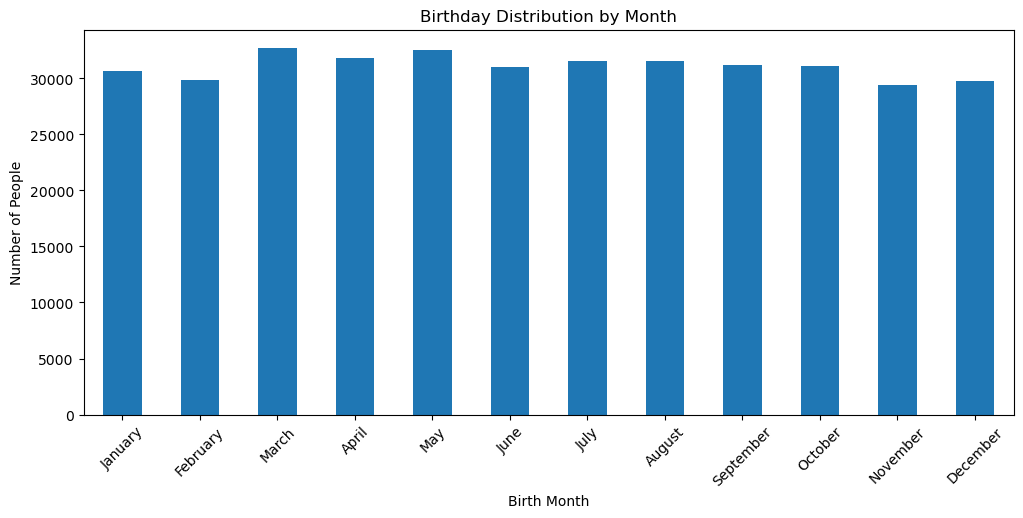

In [36]:
# Count birthdays by month using the cleaned birthday dataset
month_counts = bday['birth_month_name'].value_counts().reindex(month_order)

ax = month_counts.plot(kind='bar', figsize=(12, 5))

ax.set_title('Birthday Distribution by Month')
ax.set_xlabel('Birth Month')
ax.set_ylabel('Number of People')

plt.xticks(rotation=45)
plt.show()

In [37]:
# Convert month counts into percentages so the monthly pattern is easier to compare
month_rate = month_counts.div(month_counts.sum()).mul(100).round(2)

month_rate

birth_month_name
January      8.22
February     8.00
March        8.77
April        8.54
May          8.72
June         8.31
July         8.46
August       8.45
September    8.36
October      8.33
November     7.87
December     7.97
Name: count, dtype: float64

In [38]:
# Check missing values in the birthday fields before continuing the analysis
bday[['date_of_birth', 'birth_year', 'birth_month', 'birth_month_name', 'birth_day']].isna().sum()

date_of_birth       0
birth_year          0
birth_month         0
birth_month_name    0
birth_day           0
dtype: int64

In [39]:
# Check occupation values before grouping so I know how clean or messy this field is
notable['occupation_groups'].value_counts().head(20)

occupation_groups
Arts & Culture                                        170676
Public Figures                                        105308
Sports                                                 49265
Science & Academia                                     36361
Arts & Culture; Public Figures                         19825
Public Figures; Science & Academia                     10577
Business                                                7531
Arts & Culture; Science & Academia                      7411
Business; Public Figures                                3367
Arts & Culture; Public Figures; Science & Academia      2101
Arts & Culture; Business                                1385
Business; Science & Academia                             975
Public Figures; Sports                                   604
Arts & Culture; Sports                                   562
Arts & Culture; Business; Public Figures                 441
Business; Public Figures; Science & Academia             407
Scienc

In [40]:
# Rebuild occupation data from cleaned birthday data so Jan 1 placeholders do not skew the patterns
occ = bday.copy()

occ['occ_group'] = occ['occupation_groups'].str.split('; ')

occ = occ.explode('occ_group')

occ['occ_group'].value_counts()

occ_group
Arts & Culture        177019
Public Figures        129529
Science & Academia     50282
Sports                 50197
Business               12810
Name: count, dtype: int64

In [41]:
# Compare occupation groups by decade using percentages instead of raw counts
occ_decade = pd.crosstab(
    occ['birth_decade'],
    occ['occ_group'],
    normalize='index').mul(100).round(2)

occ_decade

occ_group,Arts & Culture,Business,Public Figures,Science & Academia,Sports
birth_decade,,,,,
1900s,44.15,1.96,32.81,16.10,4.99
1910s,43.01,2.14,34.26,15.42,5.16
1920s,43.26,2.50,31.05,17.50,5.70
1930s,43.14,3.02,28.41,19.22,6.20
1940s,39.94,3.37,33.94,18.18,4.57
1950s,36.60,3.92,39.19,15.32,4.98
1960s,40.11,4.31,38.81,11.14,5.64
1970s,47.07,3.27,32.25,7.35,10.06
1980s,46.43,2.31,19.90,3.26,28.10


### Occupation mix by birth decade

To see how the composition of notable people changes over time, I’m plotting occupation groups by decade as percentages. A 100% stacked bar chart works well here because it shows how each decade is made up across the main occupation categories.

In [42]:
colors = sns.color_palette('Set2', n_colors=occ_decade.shape[1])

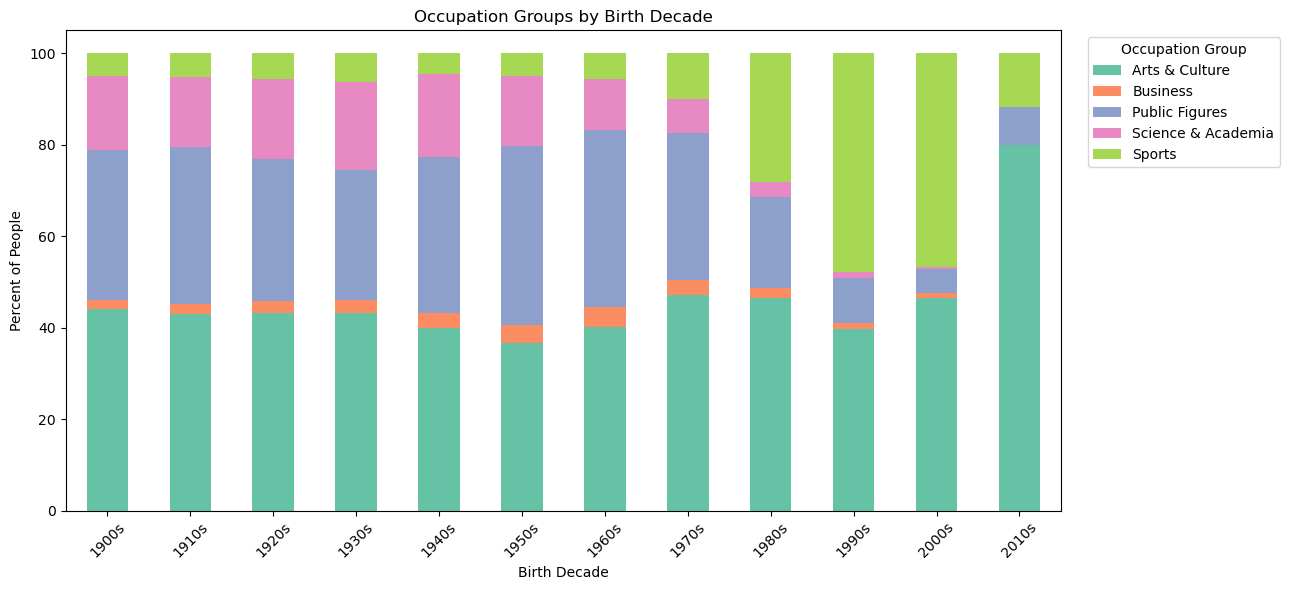

In [43]:
# Plot occupation mix by decade so the shift across time is easier to see
ax = occ_decade.plot(kind='bar', stacked=True, figsize=(13, 6), color=colors)

ax.set_title('Occupation Groups by Birth Decade')
ax.set_xlabel('Birth Decade')
ax.set_ylabel('Percent of People')
ax.legend(title='Occupation Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

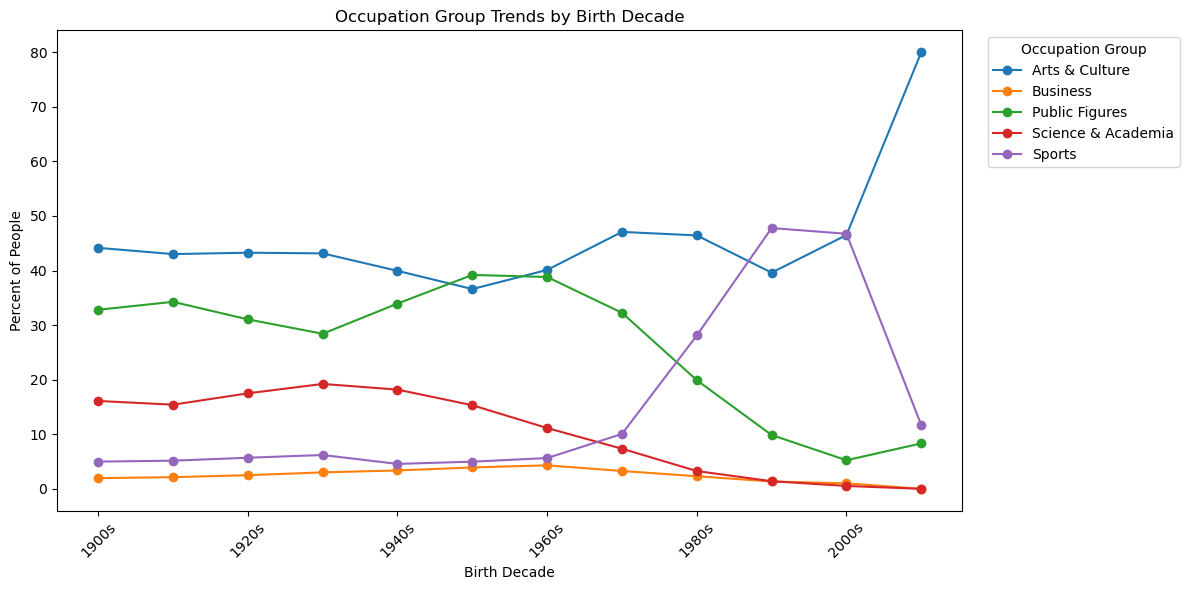

In [44]:
# Use a line chart to make the rise and fall of each occupation group easier to compare
ax = occ_decade.plot(
    kind='line',
    marker='o',
    figsize=(12, 6)
)

ax.set_title('Occupation Group Trends by Birth Decade')
ax.set_xlabel('Birth Decade')
ax.set_ylabel('Percent of People')
ax.legend(title='Occupation Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
# Keep only decades with enough records so the trend is not distorted by tiny groups
valid_decades = decade_check[decade_check['total'] >= 1000].index

occ_decade_clean = occ_decade.loc[valid_decades]

occ_decade_clean

occ_group,Arts & Culture,Business,Public Figures,Science & Academia,Sports
birth_decade,,,,,
1900s,44.15,1.96,32.81,16.10,4.99
1910s,43.01,2.14,34.26,15.42,5.16
1920s,43.26,2.50,31.05,17.50,5.70
1930s,43.14,3.02,28.41,19.22,6.20
1940s,39.94,3.37,33.94,18.18,4.57
1950s,36.60,3.92,39.19,15.32,4.98
1960s,40.11,4.31,38.81,11.14,5.64
1970s,47.07,3.27,32.25,7.35,10.06
1980s,46.43,2.31,19.90,3.26,28.10


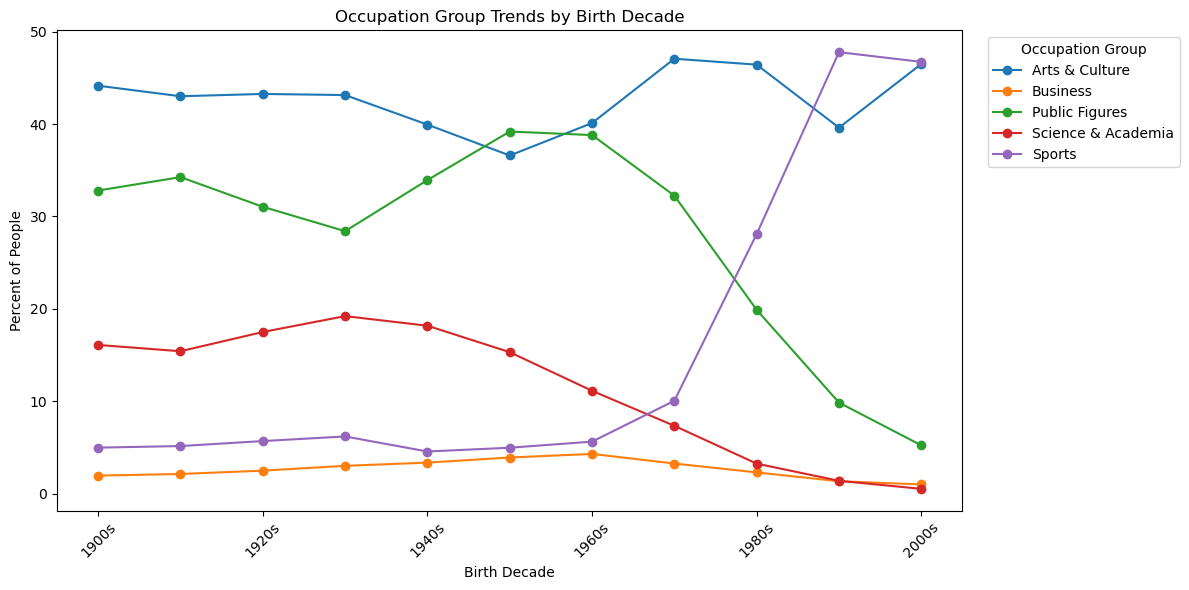

In [46]:
# Replot occupation trends using only decades with enough data
ax = occ_decade_clean.plot(kind='line', marker='o', figsize=(12, 6))

ax.set_title('Occupation Group Trends by Birth Decade')
ax.set_xlabel('Birth Decade')
ax.set_ylabel('Percent of People')
ax.legend(title='Occupation Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Occupation trends by birth decade

The occupation mix changes noticeably across birth decades. Arts & Culture stays consistently high, while Sports becomes much more common in later birth cohorts. Public Figures and Science & Academia decline in the more recent decades.

This likely reflects a mix of real cultural change and dataset bias. Modern athletes and entertainers may be more heavily represented because they are more visible, easier to document, and more likely to have complete public profiles.

It's interesting to see the changes of notable people occupations over the decades. Arts and culture are consistently high, but there's a huge jump for sports after the 60s. There's also a huge drop in public figures and a steady decline for science and academia. While I'd imagine there's some level of bias in the data set (maybe modern athletes and entertainers are easily and heavily documented), I'm curious what this says about society/culture and its values over time.

In [48]:
# Group months into seasons so I can look for broader birthday patterns beyond individual months
season_map = {
    'December': 'Winter',
    'January': 'Winter',
    'February': 'Winter',
    'March': 'Spring',
    'April': 'Spring',
    'May': 'Spring',
    'June': 'Summer',
    'July': 'Summer',
    'August': 'Summer',
    'September': 'Fall',
    'October': 'Fall',
    'November': 'Fall'}

bday['birth_season'] = bday['birth_month_name'].map(season_map)

bday['birth_season'].value_counts()

birth_season
Spring    97127
Summer    94112
Fall      91673
Winter    90271
Name: count, dtype: int64

In [49]:
# Add birth season back after rebuilding occ from the cleaned birthday dataset
occ['birth_season'] = occ['birth_month_name'].map(season_map)

In [50]:
# Convert season counts into percentages so the seasonal pattern is easier to compare
season_rate = bday['birth_season'].value_counts(normalize=True).mul(100).round(2)

season_rate

birth_season
Spring    26.03
Summer    25.22
Fall      24.57
Winter    24.19
Name: proportion, dtype: float64

### Birth season patterns

Birthdays look pretty evenly distributed across seasons, which suggests there is not a strong seasonal pattern in the overall dataset. Since the overall pattern looks normal, I want to check whether season looks different within occupation groups.

In [53]:
# Plot birth seasons to see if any part of the year is overrepresented
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

season_rate = season_rate.reindex(season_order)

In [54]:
# Add birth season to the occupation dataframe so I can compare seasons by occupation group
occ['birth_season'] = occ['birth_month_name'].map(season_map)

season_occ = pd.crosstab(
    occ['occ_group'],
    occ['birth_season'],
    normalize='index').mul(100).round(2)

season_occ = season_occ[season_order]

season_occ

birth_season,Winter,Spring,Summer,Fall
occ_group,,,,
Arts & Culture,24.16,26.12,25.05,24.67
Business,23.75,25.60,25.98,24.68
Public Figures,23.95,25.81,25.54,24.70
Science & Academia,23.94,26.19,25.06,24.81
Sports,24.92,26.17,25.10,23.81


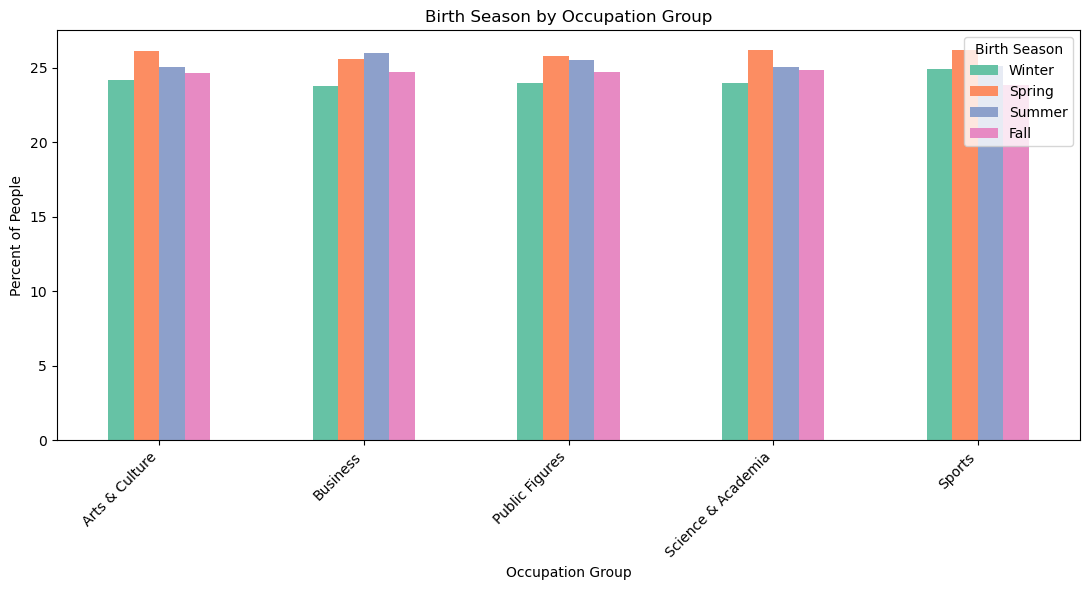

In [55]:
colors = sns.color_palette('Set2', n_colors=season_occ.shape[1])

# Plot birth season by occupation group to compare patterns across fields
ax = season_occ.plot(kind='bar', figsize=(11, 6), color=colors)

ax.set_title('Birth Season by Occupation Group')
ax.set_xlabel('Occupation Group')
ax.set_ylabel('Percent of People')
ax.legend(title='Birth Season')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [57]:
# Check birth month patterns by occupation group without going too deep into seasonality
month_occ = pd.crosstab(
    occ['occ_group'],
    occ['birth_month_name'],
    normalize='index'
).mul(100).round(2)

month_occ = month_occ[month_order]

month_occ

birth_month_name,January,February,March,April,May,June,July,August,September,October,November,December
occ_group,,,,,,,,,,,,
Arts & Culture,8.09,7.93,8.83,8.47,8.83,8.26,8.44,8.35,8.32,8.36,7.98,8.15
Business,8.04,8.05,8.70,8.25,8.64,8.46,8.54,8.98,8.43,8.31,7.93,7.66
Public Figures,8.11,7.87,8.72,8.50,8.59,8.47,8.53,8.54,8.39,8.39,7.92,7.97
Science & Academia,8.05,8.06,8.61,8.62,8.96,8.21,8.39,8.46,8.46,8.45,7.90,7.83
Sports,9.01,8.43,8.88,8.76,8.54,8.29,8.40,8.41,8.44,7.93,7.44,7.47


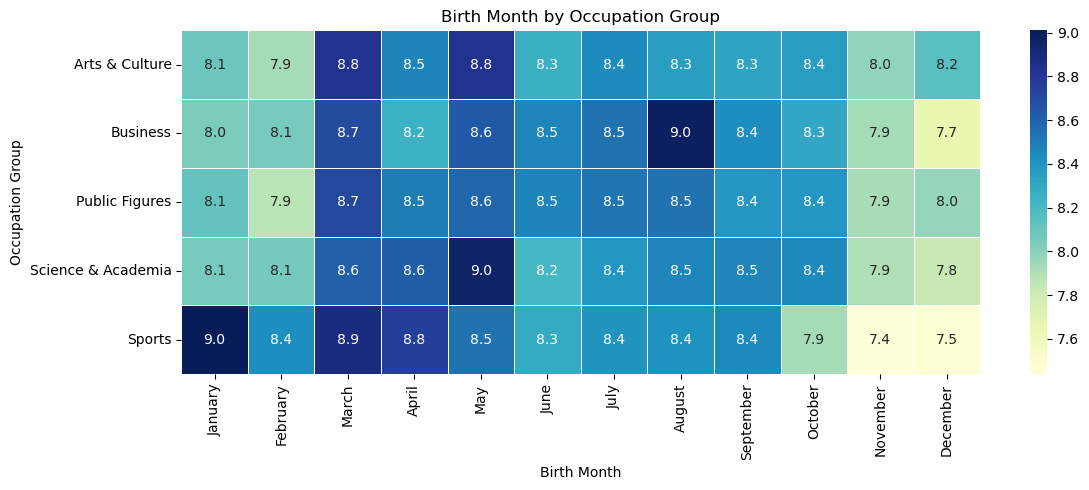

In [58]:
# Use a heatmap because the month differences are subtle and easier to read by color
plt.figure(figsize=(12, 5))

sns.heatmap(
    month_occ,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5)

plt.title('Birth Month by Occupation Group')
plt.xlabel('Birth Month')
plt.ylabel('Occupation Group')

plt.tight_layout()
plt.show()

### Occupation by Country

In [59]:
# Check the most common birth countries before comparing them with occupation groups
notable['country_of_birth'].value_counts().head(20)

country_of_birth
United States     81678
Germany           27449
Italy             18202
France            17837
Spain             17294
United Kingdom    16093
Russia            14268
Poland            12987
Canada            10782
Japan             10045
India              9716
Brazil             9245
Sweden             8555
Czech Republic     8172
Netherlands        8108
Ukraine            7626
Argentina          5536
Austria            5054
Hungary            4990
Israel             4358
Name: count, dtype: Int64

In [60]:
# Use top countries so the chart does not get overloaded with too many small groups
top_countries = notable['country_of_birth'].value_counts().head(12).index

country_occ = notable[notable['country_of_birth'].isin(top_countries)].copy()

country_occ['occ_group'] = country_occ['occupation_groups'].str.split('; ')

country_occ = country_occ.explode('occ_group')

country_occ[['country_of_birth', 'occ_group']].head()

,country_of_birth,occ_group
3,Russia,Public Figures
5,India,Arts & Culture
6,Germany,Science & Academia
7,Germany,Arts & Culture
8,Germany,Arts & Culture


In [ ]:
# Compare occupation mix by country using percentages instead of raw counts
country_mix = pd.crosstab(
    country_occ['country_of_birth'],
    country_occ['occ_group'],
    normalize='index'
).mul(100).round(2)

country_mix

In [ ]:
# Focus on smaller countries with enough records to compare without being too noisy
country_counts = notable['country_of_birth'].value_counts()

mid_countries = country_counts[
    (country_counts >= 25) & 
    (country_counts <= 250)
].index

len(mid_countries)

In [ ]:
# Preview the countries in this smaller-but-usable sample range
country_counts.loc[mid_countries].sort_values(ascending=False).head(10)

In [ ]:
country_counts.loc[mid_countries].sort_values(ascending=False).tail(10)

In [ ]:
# Build a country/occupation dataset for countries with 25 to 250 notable people
mid_occ = notable[notable['country_of_birth'].isin(mid_countries)].copy()

mid_occ['occ_group'] = mid_occ['occupation_groups'].str.split('; ')

mid_occ = mid_occ.explode('occ_group')

mid_occ[['country_of_birth', 'occ_group']].head()

In [ ]:
# Create a country by occupation table using percentages so countries can be compared fairly
mid_mix = pd.crosstab(
    mid_occ['country_of_birth'],
    mid_occ['occ_group'],
    normalize='index').mul(100).round(2)

mid_mix.head()

In [ ]:
# Compare each country to the overall occupation mix to find unusual patterns
overall_mix = mid_occ['occ_group'].value_counts(normalize=True).mul(100)

mid_diff = mid_mix.subtract(overall_mix, axis='columns').round(2)

mid_diff.head()

In [ ]:
# Focus on a few countries I want to compare more closely
focus_countries = ['Ireland', 'Philippines', 'Poland', 'Samoa']

focus = notable[notable['country_of_birth'].isin(focus_countries)].copy()

focus['country_of_birth'].value_counts()

In [ ]:
# Split occupation groups so people with multiple categories count in each relevant group
focus['occ_group'] = focus['occupation_groups'].str.split('; ')

focus = focus.explode('occ_group')

focus[['country_of_birth', 'occ_group']].head()

In [ ]:
# Compare occupation mix across the selected countries using percentages
focus_mix = pd.crosstab(
    focus['country_of_birth'],
    focus['occ_group'],
    normalize='index'
).mul(100).round(2)

focus_mix

In [ ]:
# Plot selected countries so the occupation differences are easier to see
colors = sns.color_palette('Set2', n_colors=focus_mix.shape[1])

ax = focus_mix.plot(kind='bar', figsize=(10, 6), color=colors)

ax.set_title('Occupation Mix by Selected Country')
ax.set_xlabel('Country of Birth')
ax.set_ylabel('Percent of People')
ax.legend(title='Occupation Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()